# Exercises week 37

**FYS-STK3155/4155, fall 2026 — deadline Friday September 11 at midnight.**

Solution by Erica Siekman and Jenny Lillebostad

## Implementing gradient descent for ordinary least squares and Ridge regression

The aim this week is that you write, and *check*, your own gradient descent
code for OLS and Ridge regression, and that you understand what the learning
rate can and cannot be. Everything here is reused directly in part e) of
Project 1, and exercise 6 opens part f). The code developed in the Tuesday
session (`week37tuesday.ipynb`, Case 1) is meant to be reused.

After completing these exercises you will have

* your own code for the simplest gradient descent approach applied to
  ordinary least squares (OLS) and Ridge regression, with a stopping criterion;
* compared the analytical expressions for the OLS and Ridge parameters with
  the gradient descent results;
* explored the role of the learning rate $\gamma$ in gradient descent and of the
  hyperparameter $\lambda$ in Ridge regression, and related the largest usable
  learning rate to the largest eigenvalue of the Hessian (Section 4.5 of the
  lecture notes);
* checked your analytical gradient against automatic differentiation
  (Section 4.14) and added momentum (Section 4.6);
* scaled the data properly.

Reading: Chapter 4, Sections 4.1–4.6 and 4.14 of the book; Goodfellow et al.,
Chapter 4 and Sections 8.1–8.3.

## A simple one-dimensional second-order polynomial

We start with a very simple function,

$$
f(x) = 2 - x + 5x^2,
$$

defined for $x \in [-2, 2]$. You can add noise if you wish (the Tuesday
session used Gaussian noise with standard deviation $0.5$). We fit this
function with a polynomial ansatz. The easiest thing is to set up a
second-order polynomial and see if you can recover the above function; feel
free to play around with higher-order polynomials — the Tuesday session shows
that a degree-5 fit of the same data is a much harder problem for gradient
descent, and exercise 4 asks you why.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
n = 100
x = rng.uniform(-2.0, 2.0, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)   # drop the noise term if you prefer

## Exercise 1: scale your data

Before fitting a regression model it is good practice to standardise the
features. This ensures all features are on a comparable scale, which is
especially important when using regularisation — and, as Section 4.5 of the
lecture notes shows, it is also what makes gradient descent converge in a
reasonable number of iterations. Here we standardise, scaling each feature to
have mean $0$ and standard deviation $1$.

### 1a)

Set up the design matrix $\boldsymbol{X}$ with the columns $x$ and $x^2$ (no
column of ones). Compute the mean and standard deviation of each column,
subtract the mean and divide by the standard deviation.

We also centre the target $\boldsymbol{y}$ to mean $0$. Centring
$\boldsymbol{y}$ and each feature means the model does not need a separate
intercept term: the data are shifted so that the intercept is effectively
$0$. (In practice one can include an intercept in the model and leave it
unpenalised, see Section 3.13 of the lecture notes; here we simplify by
centring.)

In [2]:
X = np.column_stack([x, x**2])

# Standardize features (zero mean, unit variance for each feature)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # safeguard to avoid division by zero for constant features
X_norm = (X - X_mean) / X_std

# Center the target to zero mean (optional, to simplify intercept handling)
y_mean = y.mean()
y_centered = y - y_mean

#verifing the centering
# Verification
print("X_norm column means:", X_norm.mean(axis=0))   # should be ~[0, 0]
print("X_norm column stds: ", X_norm.std(axis=0))     # should be ~[1, 1]
print("y_centered mean:    ", y_centered.mean())       # should be ~0

X_norm column means: [-5.88418203e-17  5.52891066e-16]
X_norm column stds:  [1. 1.]
y_centered mean:     -5.506706202140776e-16


Fill in the necessary details. Do we need to centre the $y$-values? What
would go wrong, for OLS and for Ridge, if we did not?

After this preprocessing each column of $\boldsymbol{X}_{\mathrm{norm}}$ has
mean zero and standard deviation $1$ and $\boldsymbol{y}_{\mathrm{centered}}$
has mean $0$. This makes the optimisation landscape nicer and ensures that the
penalty $\lambda\sum_j\theta_j^2$ in Ridge regression treats each coefficient
fairly, since the features are on the same scale.

Yes, we need to centre the y-values because if we dont the model needs an intercept term. If we dont do it the OLS will will need to add a column to X, and for the ridge the intercept would be penalised along with other coefficients. this could give us intercept tat would shrunk toward zero, this is not something intercept should do. When we centering we dont have to include intercept. 

### 1b)

The true function has coefficients $(-1, 5)$ on $(x, x^2)$. Which
coefficients do you expect to find on the *standardised* columns, and how do
you convert the fitted parameters back to the original scale?

In [3]:
# Expected coefficients on standardised columns
theta_expected = np.array([-X_std[0], 5 * X_std[1]])
print("Expected standardised coefficients:", theta_expected.ravel())

# Fit OLS on standardised data (no intercept needed)
theta_fitted = np.linalg.pinv(X_norm) @ y_centered
print("Fitted standardised coefficients:  ", theta_fitted.ravel())

# Convert back to original scale
beta_orig = theta_fitted.ravel() / X_std           # slope coefficients
beta_0 = y_mean - np.sum(theta_fitted.ravel() * X_mean / X_std)  # intercept
print("Original-scale coefficients (beta_1, beta_2):", beta_orig)
print("Original-scale intercept (beta_0):           ", beta_0)
print("True coefficients:                            (-1, 5), intercept 2")

Expected standardised coefficients: [-1.03870742  5.84794795]
Fitted standardised coefficients:   [-1.0773505  5.854734 ]
Original-scale coefficients (beta_1, beta_2): [-1.03720305  5.00580208]
Original-scale intercept (beta_0):            2.050198185761964
True coefficients:                            (-1, 5), intercept 2


## Exercise 2: calculate the gradients and the Hessian

Find the gradients of the OLS and Ridge cost functions,

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2,
\qquad
C_{\mathrm{Ridge}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2 + \lambda\boldsymbol{\theta}^T\boldsymbol{\theta},
$$

with respect to $\boldsymbol{\theta}$ (Eqs. (4.13) and (4.17) of the lecture
notes). Find also the Hessian matrices, and show that the OLS Hessian is
positive semi-definite and the Ridge Hessian positive definite for
$\lambda > 0$ — that is, that both cost functions are convex (Section 4.1).
Why does this matter for gradient descent?

Setting the Ridge gradient to zero, show that the minimiser is
$\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I})^{-1}\boldsymbol{X}^T\boldsymbol{y}$.
Where does the factor $n$ come from, and what is the corresponding `alpha`
of `scikit-learn`'s `Ridge`? (Section 3.10 and Eq. (3.95).)

We will find the gradient for the OLS and Ridge cost functions. the gradient is defined as $\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}) = \frac{\partial C(\theta)}{\partial \theta}$. 

first i will find the partial for OLS cost functions:
\begin{align*}
    \nabla_{\boldsymbol{\theta}} C_{\text{OLS}}(\boldsymbol{\theta}) &= \frac{\partial C_{OLS}(\boldsymbol{\theta})}{\partial \boldsymbol{\theta}} \\
    &= \frac{\partial }{\partial \boldsymbol{\theta}} \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2 \\
\end{align*}
since $\theta = \begin{pmatrix}
    \theta_0 \\ \theta_1
\end{pmatrix}$ we can derive the function on one element at time first for $\theta_0$. 
\begin{align*}
    \frac{\partial C_{OLS}(\boldsymbol{\theta})}{\partial \theta_0} 
    &= \frac{\partial }{\partial \theta_0} \frac{1}{n}\sum_{i=0}^{n-1} (\theta_0 + \theta_1 x_i)^2 - 2 y_i(\theta_0 + \theta_1 x_i) + y_i^2 \\
    &= \frac{1}{n}\sum_{i=0}^{n-1} 2(\theta_0 + \theta_1 x_i) - 2 y_i\\
    &= \frac{2}{n}\sum_{i=0}^{n-1} \theta_0 + \theta_1 x_i - y_i
\end{align*}
now for $\theta_1$
\begin{align*}
    \frac{\partial C_{OLS}(\boldsymbol{\theta})}{\partial \theta_1} 
    &= \frac{\partial }{\partial \theta_1} \frac{1}{n}\sum_{i=0}^{n-1} (\theta_0 + \theta_1 x_i)^2 - 2 y_i(\theta_0 + \theta_1 x_i) + y_i^2 \\
    &= \frac{1}{n}\sum_{i=0}^{n-1} 2(\theta_0 + \theta_1 x_i)x_i - 2x_i y_i\\
    &= \frac{2}{n}\sum_{i=0}^{n-1} x_i (\theta_0 + \theta_1 x_i - y_i)
\end{align*}
this gives us 
\begin{align*}
    \nabla_{\boldsymbol{\theta}} C_{\text{OLS}}(\boldsymbol{\theta}) &=
    \begin{pmatrix}
        \frac{\partial C_{OLS}(\boldsymbol{\theta})}{\partial \theta_0} \\ \frac{\partial C_{OLS}(\boldsymbol{\theta})}{\partial \theta_1}
    \end{pmatrix} \\
    &= \begin{pmatrix}
        \frac{2}{n}\sum_{i=0}^{n-1} \theta_0 + \theta_1 x_i - y_i \\
        \frac{2}{n}\sum_{i=0}^{n-1} x_i (\theta_0 + \theta_1 x_i - y_i)
    \end{pmatrix} \\
    &= \frac{2}{n} \boldsymbol{X}^T (\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y})
\end{align*}

to find the gradient for the ridge we use the gradient for OLS and the matrix derivation rule $\boldsymbol{X}^T\boldsymbol{X} = 2\boldsymbol{X}$. This gives us. 
\begin{align*}
    \nabla_{\boldsymbol{\theta}} C_{\text{Ridge}}(\boldsymbol{\theta}) &= \frac{\partial C_{\text{Ridge}}(\boldsymbol{\theta)}}{\partial \boldsymbol{\theta}} \\
    &= \frac{\partial }{\partial \boldsymbol{\theta}} \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2 + \lambda \boldsymbol{\theta}^T\boldsymbol{\theta} \\
    &= \nabla_{\boldsymbol{\theta}} C_{\text{OLS}}(\boldsymbol{\theta}) + \frac{\partial }{\partial \boldsymbol{\theta}} \lambda \boldsymbol{\theta}^T\boldsymbol{\theta} \\
    &= \frac{2}{n} \boldsymbol{X}^T (\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}) + 2 \lambda \boldsymbol{\theta}
\end{align*}

the hessian matrix is defined as:
\begin{align*}
    H = \begin{bmatrix}
        \frac{\partial^2 C}{\partial\theta_0^2} & \frac{\partial^2 C}{\partial\theta_0 \partial\theta_1} \\
        \frac{\partial^2 C}{\partial\theta_1 \partial\theta_0} & \frac{\partial^2 C}{\partial\theta_1^2}
    \end{bmatrix}
\end{align*}

First we look at the hessian matrix for OLS:
\begin{align*}
    \frac{\partial^2 C_{\text{OLS}}(\boldsymbol{\theta})}{\partial\theta_0^2} &=\frac{\partial}{\partial\theta_0} \frac{2}{n}\sum_{i=0}^{n-1} \theta_0 + \theta_1 x_i - y_i = \frac{2}{n} \\
    \frac{\partial^2 C_{\text{OLS}}(\boldsymbol{\theta})}{\partial\theta_0 \partial\theta_1} &= \frac{\partial^2 C}{\partial\theta_1 \partial\theta_0} = \frac{\partial}{\partial\theta_1} \frac{2}{n}\sum_{i=0}^{n-1} \theta_0 + \theta_1 x_i - y_i = \frac{2}{n}\sum_{i=0}^{n-1} x_i \\
    \frac{\partial^2 C_{\text{OLS}}(\boldsymbol{\theta})}{\partial\theta_1^2} &= 
    \frac{\partial}{\partial\theta_1} \frac{2}{n}\sum_{i=0}^{n-1} x_i (\theta_0 + \theta_1 x_i - y_i) = \frac{2}{n}\sum_{i=0}^{n-1} x_i^2
\end{align*}

this gives us the hessian matrix for OLS as:
\begin{align*}
    H_{OLS} = \frac{2}{n}\begin{bmatrix}
        1 & \sum_{i=0}^{n-1} x_i \\ \sum_{i=0}^{n-1} x_i & \sum_{i=0}^{n-1} x_i^2
    \end{bmatrix} = \frac{2}{n} \boldsymbol{X}^T\boldsymbol{X}
\end{align*}

To find the hessian matrix for ridge cost function, we can part vise derivations and get:
\begin{align*}
    H_{\text{Ridge}} = H_{\text{OLS}} + \frac{\partial}{\partial \boldsymbol{\theta}}2 \lambda \boldsymbol{\theta}
    = \frac{2}{n} \boldsymbol{X}^T\boldsymbol{X} + 2\lambda \boldsymbol{I}
\end{align*}

We now want to show that the OLS hessian is positive semi-definite. The definition for positive semi-definite is for an n x n symmetric real M matrix is said to be positive semi-definite if $x^TMx \geq 0$ for all $x$ in $\mathbb{R}^n$. \\
For our OLS hessian matrix: we set $\boldsymbol{z} \in \mathbb{R}^n$ 
\begin{align*}
    \boldsymbol{z}^T\boldsymbol{H}_{\text{OLS}}\boldsymbol{z}=
    \boldsymbol{z}^T\frac{2}{n} \boldsymbol{X}^T\boldsymbol{X}z = \frac{2}{n}\boldsymbol{z}^T \boldsymbol{X}^T\boldsymbol{X}z = \frac{2}{n} \| Xz\|^2 \geq 0
\end{align*}
this shows that the OLS hessian is positive semi-definite.

We also want to show that the Ridge hessian is positive definite. The definition of positive definite is for an n x n symmetric real M matrix is said to be positive definite if $x^TMx > 0$ for all non-zero $x$ in $\mathbb{R}^n$. \\
For our OLS hessian matrix: we set $\boldsymbol{z} \in \mathbb{R}^n \backslash \{0\}$ and $\lambda > 0$
\begin{align*}
    \boldsymbol{z}^T\boldsymbol{H}_{\text{Ridge}}\boldsymbol{z}=
    \boldsymbol{z}^T(\frac{2}{n} \boldsymbol{X}^T\boldsymbol{X} +  2\lambda \boldsymbol{I}) \boldsymbol{z} 
    = \frac{2}{n}\boldsymbol{z}^T \boldsymbol{X}^T\boldsymbol{X}\boldsymbol{z} +  2\lambda \boldsymbol{z} \boldsymbol{I} \boldsymbol{z}= \frac{2}{n} \| \boldsymbol{Xz}\|^2  + 2\lambda \| \boldsymbol{z}\|^2 > 0
\end{align*}
this shows that the Ridge hessian is positive definite.
this gives convexity that is important since then we don't have any minima to get trapped in. and every stationary point is the global minimum. 

we are now going to find the minimizer for the ridge gradient:
\begin{align*}
    \nabla_{\boldsymbol{\theta}} C_{\text{Ridge}}(\boldsymbol{\theta}) = 0 \\
    \frac{2}{n} \boldsymbol{X}^T (\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}) + 2 \lambda \boldsymbol{\theta} = 0 \\
    \frac{2}{n} \boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta} - \frac{2}{n}\boldsymbol{X}^T\boldsymbol{y} + 2 \lambda \boldsymbol{\theta} = 0 \\
    \boldsymbol{X}^T\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{X}^T\boldsymbol{y} + n \lambda \boldsymbol{\theta} = 0 \\
    \boldsymbol{\theta} (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I}) = \boldsymbol{X}^T\boldsymbol{y} \\
    \boldsymbol{\hat{\theta}}  = (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I})^{-1} \boldsymbol{X}^T\boldsymbol{y}
\end{align*}
This is the formula for the minimizer of $\theta$. The factor n comes from the length of the matrix $\boldsymbol{X}$, also how many x elements we have. 

when using scikit-learn it minimize $\| \boldsymbol{y} - \boldsymbol{X}\boldsymbol{\theta}\|_2^2 + \alpha\|\boldsymbol{\theta}\|_2^2$ for Ridge, and here $\alpha = n\lambda$. 

## Exercise 3: the analytical formulae for OLS and Ridge regression

Closed-form Ridge coefficients for lambda = 1e-05 : [-1.07733254  5.85467333]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]

Closed-form Ridge coefficients for lambda = 1.778279410038923e-05 : [-1.07731857  5.8546261 ]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]

Closed-form Ridge coefficients for lambda = 3.1622776601683795e-05 : [-1.07729371  5.85454214]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]

Closed-form Ridge coefficients for lambda = 5.623413251903491e-05 : [-1.07724951  5.85439282]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]

Closed-form Ridge coefficients for lambda = 0.0001 : [-1.07717092  5.85412731]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]

Closed-form Ridge coefficients for lambda = 0.00017782794100389227 : [-1.07703118  5.85365523]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]

Closed-form Ridge coefficients for lambda = 0.00031622776601683794 : [-1.07678277  5.85281592]
Closed-form OLS coefficients: [-1.077350

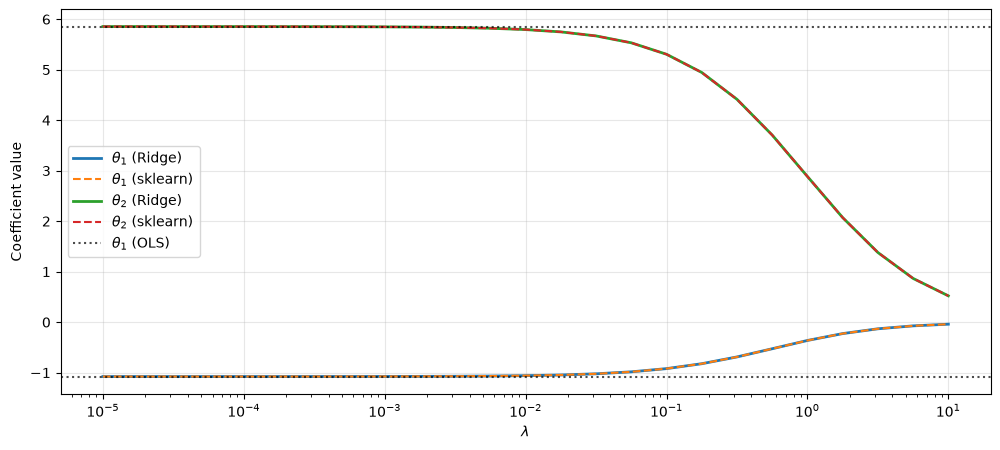

In [4]:
from sklearn.linear_model import Ridge
# Set regularization parameter, either a single value or a vector of values
# Note that lambda is a python keyword: the lambda keyword creates small anonymous functions.
lambdas = np.logspace(-5, 1, 25)
n = len(y_centered)

# Analytical forms: theta_Ridge = (X^T X + n*lambda*I)^{-1} X^T y and theta_OLS = (X^T X)^{-1} X^T y
n_features = X_norm.shape[1]
I = np.eye(n_features)

# theta vectors
theta_Ridge = np.zeros((len(lambdas), n_features))
theta_OLS = np.zeros((len(lambdas), n_features))
theta_skikit = np.zeros((len(lambdas),n_features))

for i, lam in enumerate(lambdas):
    theta_closed_formRidge = np.linalg.solve((X_norm.T @ X_norm + n * lam * I),X_norm.T @ y_centered)
    theta_closed_formOLS = np.linalg.solve((X_norm.T @ X_norm ),X_norm.T @ y_centered)
    
    model = Ridge(alpha=n*lam, fit_intercept=False)
    model.fit(X_norm, y_centered)
    theta_skikit_formRidge = model.coef_

    print("Closed-form Ridge coefficients for lambda =",lam,":", theta_closed_formRidge)
    print("Closed-form OLS coefficients:", theta_closed_formOLS)
    print()
    
    theta_Ridge[i] = theta_closed_formRidge
    theta_OLS[i] = theta_closed_formOLS
    theta_skikit[i] = theta_skikit_formRidge

print("Max |closed-form Ridge - sklearn Ridge|:", np.max(np.abs(theta_Ridge - theta_skikit)))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for j in range(n_features):
    ax.semilogx(lambdas, theta_Ridge[:, j],
                label=f'$\\theta_{j+1}$ (Ridge)', linewidth=2)
    ax.semilogx(lambdas, theta_skikit[:, j], '--',
                label=f'$\\theta_{j+1}$ (sklearn)', linewidth=1.5)

for j in range(n_features):
    ax.axhline(y=theta_OLS[0, j], color='k', linestyle=':', alpha=0.7,
               label=f'$\\theta_{j+1}$ (OLS)' if j == 0 else "")

ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('Coefficient value')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


This computes the Ridge and OLS regression coefficients directly. The identity
matrix $\boldsymbol{I}$ has the same size as $\boldsymbol{X}^T\boldsymbol{X}$
and adds $n\lambda$ to its diagonal for Ridge regression. We then solve the
linear system (prefer `np.linalg.solve` or `np.linalg.pinv` to an explicit
inverse). The result for $\boldsymbol{\theta}$ is a NumPy array of shape
`(n_features,)` containing the fitted parameters.

### 3a)

Finalise, in the above code, the OLS and Ridge regression determination of
the optimal parameters $\boldsymbol{\theta}$. Compare with
`Ridge(alpha=n*lam, fit_intercept=False)` from `scikit-learn`.

### 3b)

Explore the results as functions of different values of the hyperparameter
$\lambda$. See for example exercise 4 from week 36, and Section 3.14 of the
lecture notes for how $\lambda$ should be chosen in practice.

3b) we sees as $\lambda$ increases the Ridge shrinks the coefficeents toward zero. When $\lambda$ goes to zero the ridge coefficients becomes somular to the OLS coefficients, this makes sence since Ridge is the OLS functoin plus an extra term that is dependent on $\lambda$. When we look at the difference between the computed ridge and ridge using Skikit formulas they are identical, this shows that the my comuted formulas gives the ridge coefficients. 

## Exercise 4: implementing the simplest form of gradient descent

Alternatively we can fit the model by gradient descent, Eq. (4.15) of the
lecture notes,

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \gamma\,\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k).
$$

This is useful to visualise the iterative convergence, and it is necessary
when $n$ and $p$ are so large that the closed form is too slow or too
memory-hungry — or when, as for the Lasso, logistic regression and neural
networks, no closed form exists. Use the gradients of exercise 2 and set up,
using the template below, your own gradient descent code for OLS and Ridge
regression.

### 4a)

Write first a gradient descent code for OLS only, using the above template.
Discuss the results as functions of the learning rate and the number of
iterations: for $\gamma \in \{0.01, 0.1, 0.5, 0.8\}$, how many iterations are
needed to reach the closed-form solution of exercise 3 to a given accuracy,
say $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$?
Plot this distance against the iteration number on a logarithmic scale.

### 4b)

Write then a similar code for Ridge regression. Add a stopping criterion
based on the number of iterations *and* on the size of the gradient (or on
the difference between the new and old $\boldsymbol{\theta}$). How would you
define a stopping criterion, and what goes wrong with a fixed number of
iterations alone?

gamma=0.01: converged after 899 iterations for OLS, dist=5.56e-07
Gradient Descent OLS coefficients: [-1.07735011  5.8547336 ]
gamma=0.01: converged after 807 iterations for Ridge
Gradient Descent Ridge coefficients: [-0.92026671  5.30556797]

gamma=0.1: converged after 84 iterations for OLS, dist=4.12e-07
Gradient Descent OLS coefficients: [-1.07735021  5.85473371]
gamma=0.1: converged after 75 iterations for Ridge
Gradient Descent Ridge coefficients: [-0.92026682  5.30556809]

gamma=0.5: converged after 9 iterations for OLS, dist=2.74e-08
Gradient Descent OLS coefficients: [-1.07735048  5.854734  ]
gamma=0.5: converged after 12 iterations for Ridge
Gradient Descent Ridge coefficients: [-0.92026708  5.3055683 ]

gamma=0.8: converged after 69 iterations for OLS, dist=2.80e-07
Gradient Descent OLS coefficients: [-1.07735031  5.8547342 ]
gamma=0.8: converged after 307 iterations for Ridge
Gradient Descent Ridge coefficients: [-0.92026678  5.3055686 ]



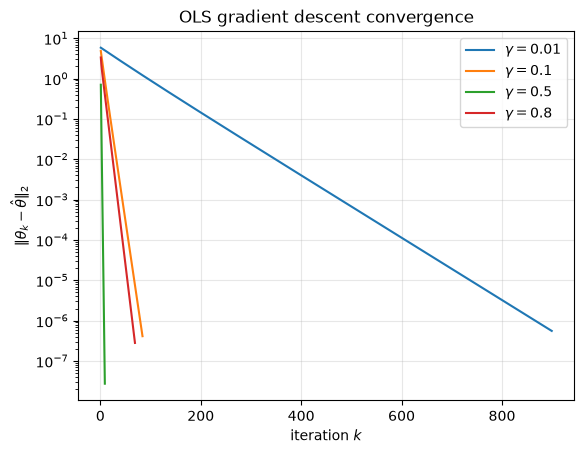

In [5]:
# Gradient descent parameters, learning rate gamma first
gammas = [0.01,0.1,0.5,0.8]
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 1000
tol = 1e-6
lam = 0.1 #lambda values 

def desent_OLS(X,y,theta_target, gamma, maxs, n, n_features, num_iters=1000):
    distances_OLS = []
    theta_gdOLS = np.zeros(n_features)
    
    # Gradient descent loops
    for t in range(num_iters):
        grad_OLS = 2/n * X.T @ (X @ theta_gdOLS - y)
        theta_gdOLS -= gamma * grad_OLS
        dist = np.linalg.norm(theta_gdOLS - theta_target)
        distances_OLS.append(dist)
        
        # Stopping criterion on gradient norm
        if np.linalg.norm(grad_OLS) < maxs:
            print(f"gamma={gamma}: converged after {t+1} iterations for OLS, dist={dist:.2e}")
            print("Gradient Descent OLS coefficients:", theta_gdOLS)
            break
    return distances_OLS

def desent_Ridge(X,y,theta_target, gamma, maxs, n, n_features, num_iters=1000):
    theta_gdRidge = np.zeros(n_features)
    distances_Ridge = []
    
    for t in range(num_iters):
        # Compute gradients for Ridge
        grad_Ridge = 2/n * X.T @ (X @ theta_gdRidge - y) + 2 * lam * theta_gdRidge #lambda = 0.01
        theta_gdRidge -= gamma * grad_Ridge
        dist = np.linalg.norm(theta_gdRidge - theta_target)
        distances_Ridge.append(dist)

        # Stopping criterion on gradient norm
        if np.linalg.norm(grad_Ridge) < maxs:
            print(f"gamma={gamma}: converged after {t+1} iterations for Ridge")
            print("Gradient Descent Ridge coefficients:", theta_gdRidge)
            break
            
    return distances_Ridge           

theta_closed_OLS = np.linalg.solve(X_norm.T @ X_norm, X_norm.T @ y_centered)
theta_closed_Ridge = np.linalg.solve(X_norm.T @ X_norm + n * lam * I, X_norm.T @ y_centered)


for gam in gammas:
    
    distances_OLS = desent_OLS(X_norm,y_centered,theta_closed_OLS, gam, tol, n, n_features, num_iters=1000)
    desent_Ridge(X_norm,y_centered,theta_closed_Ridge, gam, tol, n, n_features, num_iters=1000)

            
    # Plot of distance against the iteration number for OLS
    plt.semilogy(range(1, len(distances_OLS)+1), distances_OLS, label=f'$\\gamma = {gam}$')

    
    print()

plt.xlabel('iteration $k$')
plt.ylabel(r'$\|\theta_k - \hat{\theta}\|_2$')
plt.title('OLS gradient descent convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


4b) A stopping criterion should check that the gradient norm is less than a given max value. I have chosen the max value to be the same as for OLS, also want to show $\|\nabla C \| < 10^{-6}$ or the change $\| \theta_{k+1] - \theta_k \| < 10^{-6}$ . if we just give a fixed number of iterations we could end up with either to few iterations, this stops us before convergence, or to many iterations, that waste compution. 


### 4c) The learning rate and the eigenvalues of the Hessian

Compute the eigenvalues $\lambda_{\max}$ and $\lambda_{\min}$ of the Hessian
matrix of exercise 2 (use `np.linalg.eigvalsh`). Section 4.5 of the lecture
notes shows that gradient descent converges if and only if
$\gamma < 2/\lambda_{\max}$, Eq. (4.20), that the fastest convergence is
obtained for $\gamma^* = 2/(\lambda_{\max} + \lambda_{\min})$, and that the
number of iterations grows with the condition number
$\kappa = \lambda_{\max}/\lambda_{\min}$, Eq. (4.21). Verify the bound
numerically: run your code at $0.99 \cdot 2/\lambda_{\max}$ and at
$1.02 \cdot 2/\lambda_{\max}$.

Repeat for a design matrix with the columns $x, x^2, \dots, x^5$
(standardised). What happens to $\kappa$, to $\gamma_{\max}$ and to the number
of iterations, and why? Which of the two data sets does Ridge regression help
more, and in what sense?

gamma=0.8851419365707672: converged after 785 iterations for OLS, dist=4.38e-07
Gradient Descent OLS coefficients: [-1.0773502   5.85473431]
Upper bound gamma 0.8940827642128962
Kappa value for matrix 1.2687690135310865
Checked bond bor safe 0.8851419365707672 and unsafe 0.9119644194971541

gamma=0.3502728008178538: converged after 2168 iterations for OLS, dist=9.14e-05
Gradient Descent OLS coefficients: [-1.21071009  5.94420381  0.10300418 -0.09123299  0.04795912]
Upper bound gamma for matrix with 5 columns 0.353810909917024
Kappa value for matrix with 5 columns 520.344267456591


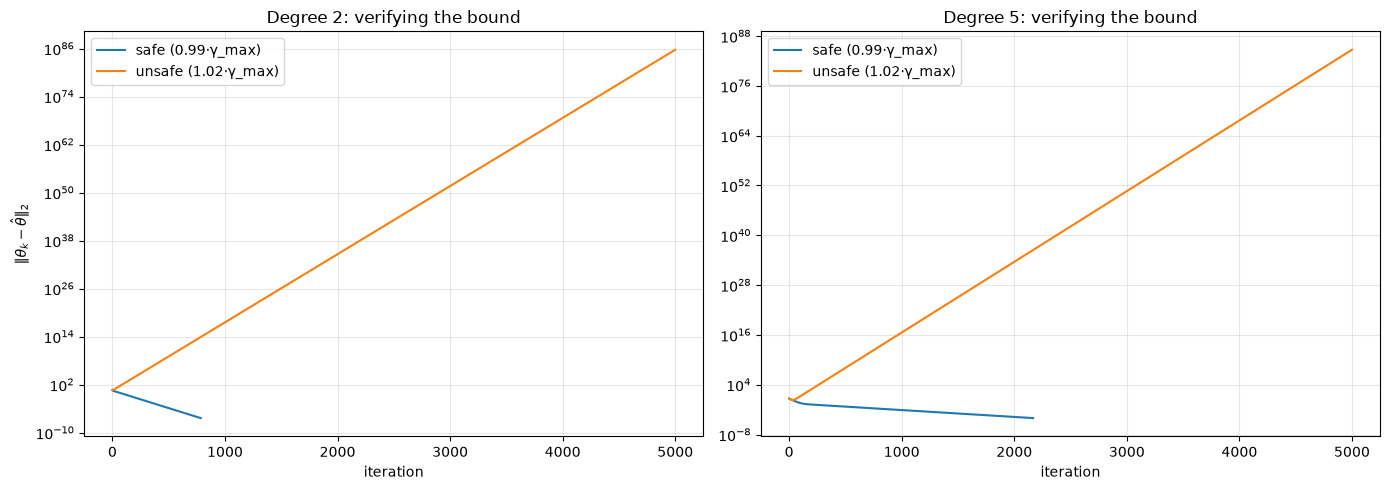

                         Degree 2     Degree 5
kappa (OLS)                   1.3        520.3
kappa (Ridge)                 1.2         27.8
gamma_max (OLS)            0.8941       0.3538
gamma=0.5000000000000001: converged after 9 iterations for OLS, dist=2.74e-08
Gradient Descent OLS coefficients: [-1.07735048  5.854734  ]
gamma=0.35313225872240533: converged after 3766 iterations for OLS, dist=2.54e-07
Gradient Descent OLS coefficients: [-1.21073263  5.94420381  0.10307553 -0.09123512  0.04790703]
gamma=0.4545454545454546: converged after 9 iterations for Ridge
Gradient Descent Ridge coefficients: [-0.92026705  5.30556832]
gamma=0.3298370390036701: converged after 202 iterations for Ridge
Gradient Descent Ridge coefficients: [-0.90569184  3.62715158 -0.11119971  1.92547467  0.12985103]


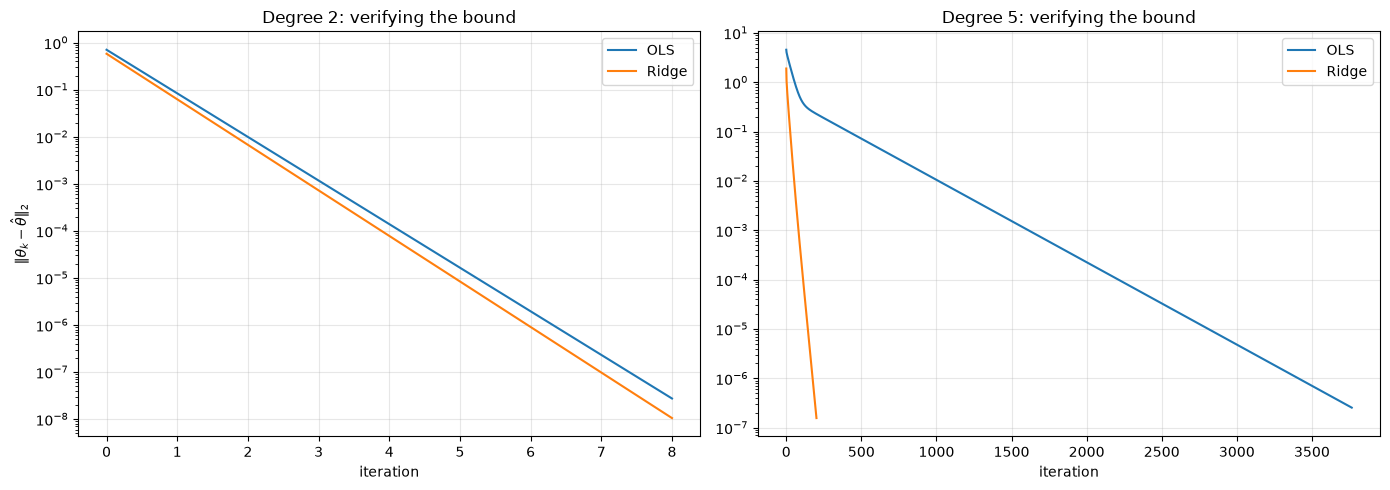

In [6]:
H_OLS = (2.0/n) * X_norm.T @ X_norm
eigenvalues_OLS = np.linalg.eigvalsh(H_OLS)
lambda_min = eigenvalues_OLS[0]
lambda_max = eigenvalues_OLS[1]

gamma_max = 2/lambda_max
gamma_opt = 2/(lambda_max + lambda_min)
kappa = lambda_max/lambda_min

#verify the bond 
safe_bond = 0.99 * gamma_max
unsafe_bond = 1.02 * gamma_max

dist_safe  = desent_OLS(X_norm, y_centered, theta_closed_OLS, safe_bond, tol, n, n_features, num_iters=5000)
dist_unsafe = desent_OLS(X_norm, y_centered, theta_closed_OLS, unsafe_bond, tol, n, n_features, num_iters=5000)

print("Upper bound gamma", gamma_max)
print("Kappa value for matrix", kappa)
print("Checked bond bor safe",safe_bond,"and unsafe", unsafe_bond)
print()

# repeat for degree_5 x,x^2,...,x^5 
X5 = np.column_stack([x, x**2, x**3, x**4, x**5])
X5_mean = X5.mean(axis=0)
X5_std = X5.std(axis=0)
X5_std[X5_std == 0] = 1  
X5_norm = (X5 - X5_mean) / X5_std
n5_features = X5.shape[1]

#thetas for 5 degree
theta_closed_OLS5 = np.linalg.solve(X5_norm.T @ X5_norm, X5_norm.T @ y_centered)
theta_closed_Ridge5 = np.linalg.solve(X5_norm.T @ X5_norm + n * 0.1 * np.eye(X5_norm.shape[1]),X5_norm.T @ y_centered)

H5_OLS = (2.0/n) * X5_norm.T @ X5_norm
eigenvalues5_OLS = np.linalg.eigvalsh(H5_OLS)
lambda5_min = eigenvalues5_OLS[0]
lambda5_max = eigenvalues5_OLS[-1]

gamma5_max = 2/lambda5_max
gamma5_opt = 2/(lambda5_max + lambda5_min)
kappa5 = lambda5_max/lambda5_min

safe5 = 0.99 * gamma5_max
unsafe5 = 1.02 * gamma5_max

dist5_safe  = desent_OLS(X5_norm, y_centered, theta_closed_OLS5, safe5, tol, n, n5_features, num_iters=5000)
dist5_unsafe = desent_OLS(X5_norm, y_centered, theta_closed_OLS5, unsafe5, tol, n, n5_features, num_iters=5000)

print("Upper bound gamma for matrix with 5 columns", gamma5_max)
print("Kappa value for matrix with 5 columns", kappa5)

#plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Degree 2
axes[0].semilogy(dist_safe,  label='safe (0.99·γ_max)')
axes[0].semilogy(dist_unsafe, label='unsafe (1.02·γ_max)')
axes[0].set_title('Degree 2: verifying the bound')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel(r'$\|\theta_k - \hat\theta\|_2$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Degree 5
axes[1].semilogy(dist5_safe,  label='safe (0.99·γ_max)')
axes[1].semilogy(dist5_unsafe, label='unsafe (1.02·γ_max)')
axes[1].set_title('Degree 5: verifying the bound')
axes[1].set_xlabel('iteration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#the same but for for ridge 

H_Ridge = (2/n) * X_norm.T @ X_norm + 2* lam * I
H5_Ridge  = (2.0/n) * X5_norm.T @ X5_norm + 2 * lam * np.eye(X5_norm.shape[1])

eigvals_ridge  = np.linalg.eigvalsh(H_Ridge)
eigvals5_ridge = np.linalg.eigvalsh(H5_Ridge)

kappa_ridge  = eigvals_ridge[-1]  / eigvals_ridge[0]
kappa5_ridge = eigvals5_ridge[-1] / eigvals5_ridge[0]

print(f"{'':20s} {'Degree 2':>12s} {'Degree 5':>12s}")
print(f"{'kappa (OLS)':20s} {kappa:12.1f} {kappa5:12.1f}")
print(f"{'kappa (Ridge)':20s} {kappa_ridge:12.1f} {kappa5_ridge:12.1f}")
print(f"{'gamma_max (OLS)':20s} {gamma_max:12.4f} {gamma5_max:12.4f}")

# OLS at optimal gamma
dist_OLS_deg2 = desent_OLS(X_norm, y_centered, theta_closed_OLS, gamma_opt, tol, n, n_features, num_iters=5000)
dist_OLS_deg5 = desent_OLS(X5_norm, y_centered, theta_closed_OLS5, gamma5_opt, tol, n, n5_features, num_iters=20000)

# Ridge at optimal gamma (use Ridge eigenvalues)
gamma_opt_ridge  = 2.0 / (eigvals_ridge[-1] + eigvals_ridge[0])
gamma_opt_ridge5 = 2.0 / (eigvals5_ridge[-1] + eigvals5_ridge[0])

dist_ridge_deg2 = desent_Ridge(X_norm, y_centered, theta_closed_Ridge, gamma_opt_ridge, tol, n, n_features, num_iters=5000)
dist_ridge_deg5 = desent_Ridge(X5_norm, y_centered, theta_closed_Ridge5, gamma_opt_ridge5, tol, n, n5_features, num_iters=5000)

#plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Degree 2
axes[0].semilogy(dist_OLS_deg2,  label='OLS')
axes[0].semilogy(dist_ridge_deg2, label='Ridge')
axes[0].set_title('Degree 2: verifying the bound')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel(r'$\|\theta_k - \hat\theta\|_2$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Degree 5
axes[1].semilogy(dist_OLS_deg5,  label='OLS')
axes[1].semilogy(dist_ridge_deg5, label='Ridge')
axes[1].set_title('Degree 5: verifying the bound')
axes[1].set_xlabel('iteration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

the $\kappa$ is the condition number, snd tells us how many iterations gradient descent will need. When you go from a design matrix with 2 colums to one with 5 colomns, the $\kappa$ value will go from 1,3 to 520,3 in OLS regression. and from 1.2 to 27.8 in ridge.This tells us that the ridge helps more the dataset with 5 colomns, since we vant $\kappa$ as close to one as possible. 
the $\gamma_{max}$ value vil decrease from 0.8941 to 0.3538 then the coloms get bigger. This tells us that the max eigenvalue got bigger, this means that the steapest direction became more steaper. 

### 4d) Checking the gradient with automatic differentiation

Project 1, part e), asks you to compute the gradient in two independent ways:
analytically, and by automatic differentiation. Write the OLS and Ridge cost
functions as ordinary Python functions of $\boldsymbol{\theta}$ using
`jax.numpy`, obtain their gradients with `jax.grad`, and compare with your
analytical gradients from exercise 2 at a random $\boldsymbol{\theta}$
(Section 4.14.7 of the lecture notes; remember
`jax.config.update("jax_enable_x64", True)`). Run your gradient descent code
with the automatic gradient and check that you obtain the same iterates.

In one or two sentences: why is automatic differentiation neither symbolic
nor numerical (finite-difference) differentiation, and what does a gradient
cost relative to one evaluation of the cost function (Section 4.14.4)?

In [8]:
def runge_data(n=100, degree=6, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta


import jax
jax.config.update("jax_enable_x64", True)     # double precision throughout
import jax.numpy as jnp
from jax import grad, jit

def cost_jax(theta, X, y):                     # Eq. (4.12), ordinary code
    return jnp.sum((X @ theta - y)**2) / len(y)

def ridge_cost_jax(theta, X, y, lam):          # Eq. (4.16)
    return jnp.sum((X @ theta - y)**2) / len(y) + lam * jnp.sum(theta**2)

X, y = runge_data()
Xj, yj = jnp.asarray(X), jnp.asarray(y)
theta = np.random.default_rng(2026).standard_normal(X.shape[1])

g_ad = np.asarray(grad(cost_jax)(jnp.asarray(theta), Xj, yj))
print("OLS:   max |AD - analytical| =", np.max(np.abs(g_ad - gradient(theta, X, y))))
g_ad = np.asarray(grad(ridge_cost_jax)(jnp.asarray(theta), Xj, yj, 0.1))
print("Ridge: max |AD - analytical| =", np.max(np.abs(g_ad - gradient(theta, X, y, 0.1))))

# the derivative with respect to lambda, argument number 3: theta^T theta by Eq. (4.16)
print("dC/dlambda =", float(grad(ridge_cost_jax, argnums=3)(jnp.asarray(theta), Xj, yj, 0.1)),
      " theta^T theta =", theta @ theta)

# what single precision would have given
g32 = grad(ridge_cost_jax)(jnp.asarray(theta, dtype=jnp.float32), jnp.asarray(X, dtype=jnp.float32),
                           jnp.asarray(y, dtype=jnp.float32), jnp.float32(0.1))
print("Ridge in float32: max |AD - analytical| =", np.max(np.abs(np.asarray(g32) - gradient(theta, X, y, 0.1))))

OLS:   max |AD - analytical| = 4.440892098500626e-16
Ridge: max |AD - analytical| = 8.881784197001252e-16
dC/dlambda = 6.723862003906883  theta^T theta = 6.723862003906882
Ridge in float32: max |AD - analytical| = 5.169319439168873e-07


## Exercise 5: Ridge regression and a new synthetic data set

We create a synthetic linear regression data set with a sparse underlying
relationship: many features, of which only a few contribute to the target. We
use 10 features with only 3 non-zero weights in the true model, so that the
target is a linear combination of a few features (with known coefficients)
plus random noise. The steps are:

* decide on the number of samples and features (100 samples, 10 features);
* define the *true* coefficient vector with mostly zeros, for example
  $\boldsymbol{\theta}_{\mathrm{true}} = [5.0, -3.0, 0, 0, 0, 0, 2.0, 0, 0, 0]$,
  meaning only features 0, 1 and 6 have a real effect on $y$;
* sample the feature matrix $\boldsymbol{X}$ from a standard normal
  distribution, so that the features are roughly centred around 0;
* compute $\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta}_{\mathrm{true}} + \boldsymbol{\varepsilon}$
  with Gaussian noise $\boldsymbol{\varepsilon}$.

In [9]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(0)

# Define dataset size
n_samples = 100
n_features = 10
lam = 0.1

# Define true coefficients (sparse linear relationship)
theta_true = np.array([5.0, -3.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0])

# Generate feature matrix X (n_samples x n_features) with random values
X = np.random.randn(n_samples, n_features)  # standard normal distribution

# Generate target values y with a linear combination of X and theta_true, plus noise
noise = 0.5 * np.random.randn(n_samples)    # Gaussian noise
y = X @ theta_true + noise

# 1. Feature Scaling (Z-score normalization as in Exercise 1)
def scale_features(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Avoid division by zero for intercept column if present
    std[std == 0] = 1.0 
    X_scaled = (X - mean) / std
    return X_scaled, mean, std

# Assume X (without intercept) and y are already defined from your dataset
X_scaled, X_mean, X_std = scale_features(X)
# Add intercept column after scaling
X_design = np.c_[np.ones(X_scaled.shape[0]), X_scaled]

n, p = X_design.shape
lmbda = 0.1 # Example Ridge penalty parameter

# 2. Analytical Solutions
beta_ols_analytical = np.linalg.pinv(X_design.T @ X_design) @ X_design.T @ y

# For Ridge, do not penalize the intercept (first column)
I_matrix = np.eye(p)
I_matrix[0, 0] = 0 
beta_ridge_analytical = np.linalg.inv(X_design.T @ X_design + lmbda * I_matrix) @ X_design.T @ y

# 3. Custom Gradient Descent Loop (Example for Ridge)
def gradient_descent_ridge(X, y, lmbda, lr=0.01, epochs=1000):
    n, p = X.shape
    beta = np.zeros(p)
    I_matrix = np.eye(p)
    I_matrix[0, 0] = 0 # Do not penalize intercept
    
    for epoch in range(epochs):
        # Gradient of Ridge loss
        gradient = (2/n) * X.T @ (X @ beta - y) + (2 * lmbda / n) * (I_matrix @ beta)
        beta -= lr * gradient
    return beta

beta_ridge_gd = gradient_descent_ridge(X_design, y, lmbda)

# 4. Condition Number of the Hessian
Hessian_ols = (2 / n) * (X_design.T @ X_design)
Hessian_ridge = (2 / n) * (X_design.T @ X_design) + (2 * lmbda / n) * I_matrix

cond_ols = np.linalg.cond(Hessian_ols)
cond_ridge = np.linalg.cond(Hessian_ridge)

print(f"Condition Number (OLS Hessian): {cond_ols:.2f}")
print(f"Condition Number (Ridge Hessian): {cond_ridge:.2f}")



Condition Number (OLS Hessian): 2.27
Condition Number (Ridge Hessian): 2.26


The Condition Numbers converge more easily in exercise five compared to exercise 4c, because the we're comparing the maximum eigen values with the minimum eigen values. In Exercise 5, the difference between our maximum and mimimum Eigen values is smaller than in exercise 4c, creating an easier convergence.

This code produces a data set where only features 0, 1 and 6 significantly
influence $\boldsymbol{y}$; the rest have zero true coefficient. Feature 0 has
a true weight of $5.0$, feature 1 of $-3.0$ and feature 6 of $2.0$, so the
expected relationship is

$$
y \approx 5x_0 - 3x_1 + 2x_6 + \text{noise}.
$$

You can remove the noise if you wish.

Fit the above data set using OLS and Ridge regression with the analytical
expressions and with your own gradient descent code (scale the data as in
exercise 1). If everything works, the learned coefficients should be close to
the true values $[5.0, -3.0, 0, \dots, 2.0, \dots]$. Due to regularisation
and noise the learned values will not exactly equal the true ones, but they
should be in the same ballpark. Which method, OLS or Ridge, gives the best
results — and best in which sense? Compute the condition number of the
Hessian for this data set: why does gradient descent converge so much more
easily here than for the degree-5 polynomial of exercise 4c)?

## Exercise 6: adding momentum

Part f) of Project 1 asks you to extend your gradient descent code with
momentum and, next week, with the adaptive methods AdaGrad, RMSProp and Adam.
Start here with momentum, Eq. (4.23) of the lecture notes,

$$
\boldsymbol{v}_{k+1} = \beta\boldsymbol{v}_k + \gamma\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k),
\qquad
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \boldsymbol{v}_{k+1},
$$

which is one line more than the code of exercise 4. Use the degree-5
polynomial data of exercise 4c), where plain gradient descent is slow, and
the learning rate $\gamma = 0.9 \cdot 2/\lambda_{\max}$.

1. Run $\beta \in \{0, 0.5, 0.9\}$ and count the iterations needed to reach
   $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$. Plot
   the three convergence curves on a logarithmic scale.
2. Section 4.6 shows that, with optimally tuned parameters, momentum reduces
   the iteration count from $\propto\kappa$ to $\propto\sqrt\kappa$,
   Eq. (4.26). How large a reduction do you observe with the fixed $\gamma$
   above, and how does it compare with $\sqrt\kappa$? Try the optimal
   momentum $\beta^* = \big((\sqrt\kappa-1)/(\sqrt\kappa+1)\big)^2$.
3. Explain, in terms of Eqs. (4.24) and (4.25), why momentum speeds up the
   flat directions and damps the oscillations in the steep ones.
4. (Optional) Repeat with $\gamma = 1.5 \cdot 2/\lambda_{\max}$, where plain
   gradient descent diverges. What happens with momentum, and why?

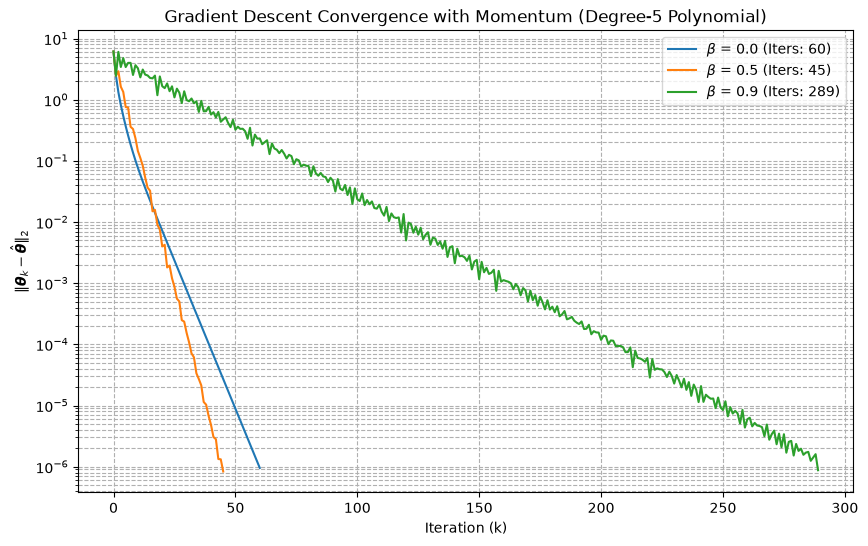

In [10]:
# Your momentum code here# Assume X_design (Vandermonde matrix for degree-5 poly) and y are defined
# Intercept is assumed included. Scale data columns 1 to 5 as in Exercise 1.

n, p = X_design.shape
Hessian = (2.0 / n) * (X_design.T @ X_design)
eigenvalues = np.linalg.eigvalsh(Hessian)
lambda_max = eigenvalues[-1]
lambda_min = eigenvalues[0]
kappa = lambda_max / lambda_min

# True/analytical OLS solution to compare against
theta_hat = np.linalg.pinv(X_design) @ y

gamma = 0.9 * (2.0 / lambda_max)
betas = [0.0, 0.5, 0.9]
tolerance = 1e-6
max_iters = 100000

history = {b: [] for b in betas}
iterations_needed = {}

for beta in betas:
    theta = np.zeros(p)
    v = np.zeros(p)
    
    for k in range(max_iters):
        error = np.linalg.norm(theta - theta_hat)
        history[beta].append(error)
        
        if error < tolerance:
            iterations_needed[beta] = k
            break
            
        # Gradient of OLS Cost Function: C(theta) = (1/n) * ||X*theta - y||^2
        grad = (2.0 / n) * X_design.T @ (X_design @ theta - y)
        
        # Momentum updates
        v = beta * v + gamma * grad
        theta = theta - v
    else:
        iterations_needed[beta] = max_iters

# Plotting the convergence curves
plt.figure(figsize=(10, 6))
for beta in betas:
    plt.plot(history[beta], label=f"$\\beta$ = {beta} (Iters: {iterations_needed.get(beta, 'Max')})")
plt.yscale('log')
plt.xlabel('Iteration (k)')
plt.ylabel('$\|\\boldsymbol{\\theta}_k - \\hat{\\boldsymbol{\\theta}}\\|_2$')
plt.title('Gradient Descent Convergence with Momentum (Degree-5 Polynomial)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| My loop stopped after its allowed iterations with a small but nonzero gradient. Has it converged? | No. Along the slowest direction the error contracts by $\lvert 1-\gamma\lambda_{\min}\rvert$ per step, Eq. (4.19), and can still be $\|\nabla C\|/\lambda_{\min}$ large. Stop on the gradient (or on $\Delta\boldsymbol{\theta}$), never on a count alone. |
| Why does gradient descent care about the scaling of the columns when the closed form does not? | The closed form solves the normal equations in one go; gradient descent takes the same step in every direction, and the column scales set the eigenvalue spread $\kappa(\boldsymbol{H}) = \kappa_2(\boldsymbol{X})^2$, Eq. (4.22), hence the iteration count. Same minimum, different road. |
| Ridge converged in far fewer iterations than OLS. Did it find a better OLS solution? | No — it found the exact solution of a *different* problem, Eq. (4.16). The penalty lifts $\lambda_{\min}$, Eq. (4.17), which shortens the road, but the destination moved: bias traded for variance. |
| The same code diverged at $\gamma = 0.5$ on one data set and converged at $\gamma = 0.8$ on another. Why? | Stability requires $\gamma < 2/\lambda_{\max}$, Eq. (4.20), and $\lambda_{\max}$ is a property of $\boldsymbol{X}$, not of the algorithm. Compute it — `np.linalg.eigvalsh(2/n * X.T @ X).max()` — before you choose $\gamma$. |
| The closed form and my converged gradient descent disagree in the second decimal for Ridge. Which is wrong? | Possibly neither: with the cost $\frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|^2 + \lambda\|\boldsymbol{\theta}\|^2$ the closed form has $n\lambda\boldsymbol{I}$, Eq. (3.95), and `scikit-learn`'s `alpha` is $n\lambda$. Compare cost functions before comparing methods. |
| My JAX gradient agrees with my analytical gradient to $10^{-15}$. What have I proved? | That your derivation matches the cost you *wrote down* — an algebra error would show as $10^{-2}$. Not that the cost is the one you meant (a missing $1/n$, a penalised intercept): both gradients would then agree and both would be wrong. |
| Momentum converged where plain gradient descent diverged. Is the learning rate now unimportant? | No. The stability edge moves to $2(1+\beta)/\lambda_{\max}$, and the best $\beta$ is tied to $\kappa$ through Eq. (4.26); too much momentum rings for ever. Two data-dependent knobs instead of one. |
| Why does momentum help, in one sentence? | It adds up gradients that keep pointing the same way (the flat directions, effective step $\gamma/(1-\beta)$, Eq. (4.25)) and cancels gradients that alternate in sign (the steep direction), so the iteration count scales with $\sqrt\kappa$ instead of $\kappa$. |
| I swap the OLS cost for a neural-network cost and keep `jax.grad`. What changes? | In the code: only the definition of the cost. In the theory: convexity is gone, so a stationary point need not be the global minimum (Section 4.1) and the bound of Eq. (4.20) is only local — good behaviour becomes empirical, not a theorem. |
| Why reverse mode for training, and what is its price? | One scalar output and $p$ inputs: reverse mode returns the full gradient for two or three cost evaluations, whatever $p$ (the cheap gradient principle, Section 4.14.4); forward mode or finite differences would need $p$ sweeps. The price is the tape — every intermediate value is stored until the backward sweep has used it: memory, not time. |
| Why not just use finite differences to check the gradient, and be done with it? | For a *quadratic* cost the central difference is exact up to rounding, so it would pass; for anything else its best accuracy is about $10^{-11}$ at $h\approx10^{-6}$, Eq. (4.46), and it costs $2p$ evaluations. Use it as a check at $h \approx 10^{-5}$, not as the gradient. |

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 11 at midnight**. Collaboration is encouraged — list
your collaborators.